### MATH-8442 HW-5.3
#### The initial part of this Jupyter Notebook contains code 
#### For the solutions, please scroll down further 

### Given: 
- $u_t = u_{xx} +f(x,t) \qquad 0 < x < 1$
- Boundary conditions
    - $u(x,0) = \cos(5\pi x) $
    - $u(0,t) = \cos(t) $
    - $u(1,t) = -\cos(t)$
- Force term
    - $f(x,t) = -\cos(5 \pi x) \sin(t) + (5 \pi)^2 \cos(5 \pi x) \cos(t)$

In [165]:
import numpy as np
import matplotlib.pyplot as plt

In [166]:
# Force term and exact solution 
from numpy import cos as COS
from numpy import sin as SIN
from numpy import pi as PI 

# f(x,t) = -cos(5 π x) sin(t) + (5 π)^2 cos(5 π x) cos(t)
def f(x,t):
    return (5*PI) * (5*PI) * COS(5*PI*x) * COS(t) - COS(5*PI*x)*SIN(t) 

# u(x,t) = cos(5 π x) cos(t) 
def u_exact(x,t):
    return COS(5*PI*x) * COS(t) 

<hr style="height: 10px; border: none; background-color: yellow;">


## Forward Euler Method
Suppose there $N$ grid points in space. \
Then $u_0$ and $u_{N-1}$ are the 2 boundary points. \
$u_1, u_2, \cdots u_{N-2}$ are the $N-2$ interior points \
$f_1, f_2, \cdots f_{N-2} $ are the forcing terms evaluated at the $N-2$ interior points \
let $\sigma = k/h^2$
$$
\begin{bmatrix}
u_1 \\ 
u_2 \\
u_3 \\
\vdots \\ 
u_{N-3} \\
u_{N-2}
\end{bmatrix}_{N-2 \times 1} ^{(l+1)}
= \begin{bmatrix}
1-2\sigma & \sigma        &  0     & 0      & 0      & \cdots & 0 & 0 & 0\\
\sigma      & 1-2\sigma   & \sigma     & 0      & 0      & \cdots & 0 & 0 & 0\\
0       & \sigma     & 1-2\sigma   & \sigma     & 0      & \cdots & 0 & 0 & 0\\
\vdots  & \vdots & \ddots & \ddots & \ddots & \cdots & 0 & 0 & 0\\
0       & 0      & 0      & 0      & 0      & \cdots & 1-2\sigma & \sigma & 0 \\
0       & 0      & 0      & 0      & 0      & \cdots & \sigma & 1-2\sigma & \sigma \\
\end{bmatrix}_{N-2 \times N-2}
\begin{bmatrix}
u_1 \\ 
u_2 \\
u_3 \\
\vdots \\ 
u_{N-3} \\
u_{N-2}
\end{bmatrix}_{N-2 \times 1} ^{(l)}
+ 
\sigma \begin{bmatrix}
u_0 \\ 
0 \\
0 \\
\vdots \\ 
0 \\
u_{N}
\end{bmatrix}_{N-2 \times 1} ^{(l)}
+ 
k \begin{bmatrix}
f_1 \\ 
f_2 \\
f_3 \\
\vdots \\ 
f_{N-3} \\
f_{N-2}
\end{bmatrix}_{N-2 \times 1} ^{(l)}
$$


In [167]:
# u0t : boundary condition u(x=0,t) 
# u1t : boundary condition u(x=1,t) 
# ux0 : boundary condntion u(x,t=0) 
# xgrid : space grid points
# tgrid : time grid points

def solveFE(xgrid, tgrid, u0t, u1t, ux0): 
    N = xgrid.shape[0]
    L = tgrid.shape[0]
    h = xgrid[1] - xgrid[0]
    k = tgrid[1] - tgrid[0]
    s = k / (h**2)
    
    u_grid = [ux0.copy()] # store the solution for the full grid (not necessary)
    
    # Tridiagonal second-difference matrix
    e = np.ones(N-2)
    A = (
        np.diag(-2.0 * e)
        + np.diag(e[:-1], k=1)
        + np.diag(e[:-1], k=-1)
    )

    A2 = np.eye(N-2) + s * A

    # start iteration at t=0 boundary condition
    u = ux0.copy() 
    
    for l in range(L-1):
        tl = tgrid[l]     # timestep l
        tlp1 = tgrid[l+1] # timestep l+1
        uint = u[1:N-1]   # interior points

        # the boundary term evaluated at timestep l
        boundary_l     = np.zeros(N-2)
        boundary_l[0]  = u0t[l]
        boundary_l[-1] = u1t[l]

        # force term at timestep l
        forcing_l = f(xgrid[1:N-1],tl)
        
        # RHS of FE equation
        rhs = A2 @ uint + s*boundary_l + k*forcing_l

        # interior points at timestep l+1
        uint_new = rhs

        # all points at timestep l+1
        # concat boundary points uexact(0,k*(l+1)) and uexact(1, k*(l+1))
        u = np.concatenate((
            [u0t[l+1]],
             uint_new,
            [u1t[l+1]]
        ))

        u_grid.append(u.copy())

    return np.array(u_grid)

### Forward Euler is stable only if $\frac{k}{h^2} \le \frac{1}{2}$

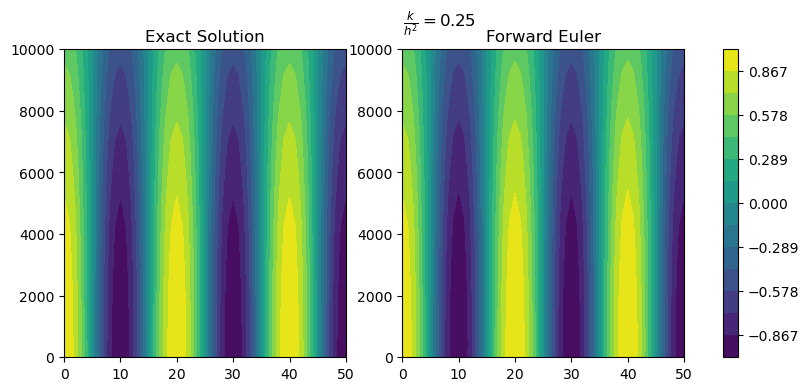

In [168]:
# FE is stable only if k/h^2 <= 0.5

# discretization
xmin,xmax = 0.0 , 1.0
tmin,tmax = 0.0 , 1.0
xsteps,tsteps = 51 , 10001 # k/h^2 = 0.25
xgrid = np.linspace(xmin,xmax,xsteps)
tgrid = np.linspace(tmin,tmax, tsteps)
X,T = np.meshgrid(xgrid,tgrid)

# evaluate sigma
h = xgrid[1] - xgrid[0]
k = tgrid[1] - tgrid[0]
s = k/(h**2)

# evaluate boundary terms
u0t = u_exact(xmin,tgrid) # evaluate boundary condition on the grid at x = 0
u1t = u_exact(xmax,tgrid) # evaluate boundary condition on the grid at x = 1
ux0 = u_exact(xgrid,tmin) # evaluate boundary condition on the grid at t = 0

# evalute Forward Euler solution
u_grid_fe = solveFE(xgrid, tgrid, u0t, u1t, ux0)

# evaluate exact solution
u_grid_exact = u_exact(X,T) 

# determine global min/max for shared scale of exact-solution and FE-solution
_min = min(u_grid_exact.min(), u_grid_fe.min())
_max = max(u_grid_exact.max(), u_grid_fe.max())
levels = np.linspace(_min, _max, 15)

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
cf1 = ax1.contourf(u_grid_exact, levels=levels)
cf2 = ax2.contourf(u_grid_fe, levels=levels)
ax1.set_title("Exact Solution")
ax2.set_title("Forward Euler")
fig.suptitle(f"$\\frac{{k}}{{h^2}} = {s}$")
fig.colorbar(cf1, ax=[ax1, ax2])
plt.show()

<hr style="height: 10px; border: none; background-color: yellow;">


## Backwards Euler Method
Suppose there $N$ grid points in space. \
Then $u_0$ and $u_{N-1}$ are the 2 boundary points. \
$u_1, u_2, \cdots u_{N-2}$ are the $N-2$ interior points \
$f_1, f_2, \cdots f_{N-2} $ are the forcing terms evaluated at the $N-2$ interior points \
let $ \sigma = k/h^2$
$$ 
\begin{bmatrix}
1+2\sigma & -\sigma        &  0     & 0      & 0      & \cdots & 0 & 0 & 0\\
-\sigma      & 1+2\sigma   & -\sigma     & 0      & 0      & \cdots & 0 & 0 & 0\\
0       & -\sigma     & 1+2\sigma   & -\sigma     & 0      & \cdots & 0 & 0 & 0\\
\vdots  & \vdots & \ddots & \ddots & \ddots & \cdots & 0 & 0 & 0\\
0       & 0      & 0      & 0      & 0      & \cdots & 1+2\sigma & -\sigma & 0 \\
0       & 0      & 0      & 0      & 0      & \cdots & -\sigma & 1+2\sigma & -\sigma \\
\end{bmatrix}_{N-2 \times N-2}
\begin{bmatrix}
u_1 \\ 
u_2 \\
u_3 \\ 
\vdots \\ 
u_{N-3} \\
u_{N-2}
\end{bmatrix}_{N-2 \times 1}^{(l+1)}
= \begin{bmatrix}
u_1 \\ 
u_2 \\
u_3 \\ 
\vdots \\ 
u_{N-3} \\
u_{N-2}
\end{bmatrix}_{N-2 \times 1}^{(l)}
+ 
\sigma \begin{bmatrix}
u_0 \\ 
0 \\
0 \\
\vdots \\ 
0 \\
u_{N}
\end{bmatrix}_{N-2 \times 1}^{(l+1)}
+ 
k \begin{bmatrix}
f_1 \\ 
f_2 \\
f_3 \\ 
\vdots \\ 
f_{N-3} \\
f_{N-2}
\end{bmatrix}_{N-2 \times 1}^{(l+1)}
$$

In [169]:
# u0t : boundary condition u(x=0,t) 
# u1t : boundary condition u(x=1,t) 
# ux0 : boundary condntion u(x,t=0) 
# xgrid : space grid points
# tgrid : time grid points

def solveBE(xgrid, tgrid, u0t, u1t, ux0): 
    N = xgrid.shape[0]
    L = tgrid.shape[0]
    h = xgrid[1] - xgrid[0]
    k = tgrid[1] - tgrid[0]
    s = k / (h**2)
    
    # Tridiagonal second-difference matrix
    e = np.ones(N-2)
    A = (
        np.diag(-2.0 * e)
        + np.diag(e[:-1], k=1)
        + np.diag(e[:-1], k=-1)
    )

    u_grid = [ux0.copy()] # store the solution for the full grid (not necessary)
    
    A1 = np.eye(N-2) - s * A

    # start iteration at t=0 boundary condition
    u = ux0.copy() 
    
    for l in range(L-1):
        tl = tgrid[l]     # timestep = l
        tlp1 = tgrid[l+1] # timestep = l+1
        uint = u[1:N-1]   # interior points

        # the boundary term evaluated at timestep l+1
        boundary_lp1     = np.zeros(N-2)
        boundary_lp1[0]  = u0t[l+1]
        boundary_lp1[-1] = u1t[l+1]

        # force term at timestep l+1
        forcing_lp1 = f(xgrid[1:N-1],tlp1)
        
        # RHS of BE equation
        rhs = uint + s*boundary_lp1 + k*forcing_lp1

        # interior points at timestep l+1
        uint_new = np.linalg.solve(A1,rhs)

        # all points at timestep l+1
        # concat boundary points uexact(0,k*(l+1)) and uexact(1, k*(l+1))
        u = np.concatenate((
            [u0t[l+1]],
            uint_new,
            [u1t[l+1]]
        ))
        u_grid.append(u.copy())

    return np.array(u_grid)

### Backward-Euler is unconditionally stable

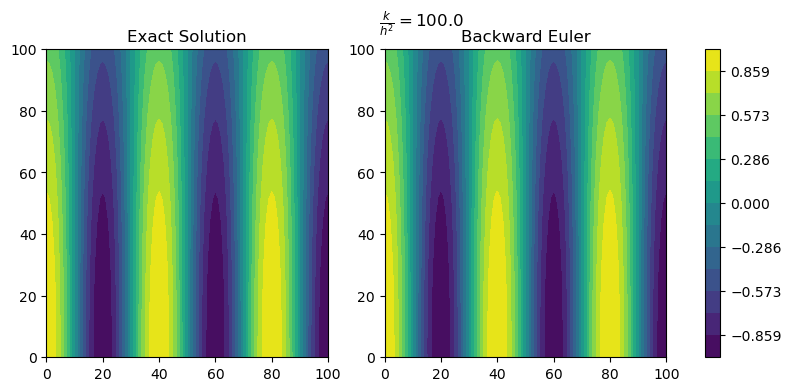

In [170]:
# BE is unconditionally stable

# discretization
xmin,xmax = 0.0,1.0
tmin,tmax = 0.0,1.0
xsteps,tsteps = 101,101 # k/h^2 = 100
xgrid = np.linspace(xmin,xmax,xsteps)
tgrid = np.linspace(tmin,tmax, tsteps)
X,T = np.meshgrid(xgrid,tgrid)

# evaluate boundary terms
u0t = u_exact(xmin,tgrid) # evaluate boundary condition on the grid at x = 0
u1t = u_exact(xmax,tgrid) # evaluate boundary condition on the grid at x = 1
ux0 = u_exact(xgrid,tmin) # evaluate boundary condition on the grid at t = 0

# evaluate sigma
h = xgrid[1] - xgrid[0]
k = tgrid[1] - tgrid[0]
s = k/(h**2)

# evalute Backwards-Euler solution
u_grid_be = solveBE(xgrid, tgrid, u0t, u1t, ux0)

# evaluate exact solution
u_grid_exact = u_exact(X,T) 

# global min/max for shared scale of exact-solution and BE-solution
_min = min(u_grid_exact.min(), u_grid_be.min())
_max = max(u_grid_exact.max(), u_grid_be.max())
levels = np.linspace(_min, _max, 15)

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
cf1 = ax1.contourf(u_grid_exact, levels=levels)
cf2 = ax2.contourf(u_grid_be, levels=levels)
ax1.set_title("Exact Solution")
ax2.set_title("Backward Euler")
fig.suptitle(f"$\\frac{{k}}{{h^2}} = {s}$")
fig.colorbar(cf1, ax=[ax1, ax2])
plt.show()


<hr style="height: 10px; border: none; background-color: yellow;">


## Crank-Nicolson Equation
$\sigma = k/2h^2$
$$ 
\begin{bmatrix}
1+2\sigma & -\sigma        &  0     & 0      & 0      & \cdots & 0 & 0 & 0\\
-\sigma      & 1+2\sigma   & -\sigma     & 0      & 0      & \cdots & 0 & 0 & 0\\
0       & -\sigma     & 1+2\sigma   & -\sigma     & 0      & \cdots & 0 & 0 & 0\\
\vdots  & \vdots & \ddots & \ddots & \ddots & \cdots & 0 & 0 & 0\\
0       & 0      & 0      & 0      & 0      & \cdots & 1+2\sigma & -\sigma & 0 \\
0       & 0      & 0      & 0      & 0      & \cdots & -\sigma & 1+2\sigma & -\sigma \\
\end{bmatrix}_{N-2 \times N-2}
\begin{bmatrix}
u_1 \\ 
u_2 \\
u_3 \\
\vdots \\ 
u_{N-3} \\
u_{N-2}
\end{bmatrix}_{N-2 \times 1} ^{(l+1)}
= \begin{bmatrix}
1-2\sigma & \sigma        &  0     & 0      & 0      & \cdots & 0 & 0 & 0\\
\sigma      & 1-2\sigma   & \sigma     & 0      & 0      & \cdots & 0 & 0 & 0\\
0       & \sigma     & 1-2\sigma   & \sigma     & 0      & \cdots & 0 & 0 & 0\\
\vdots  & \vdots & \ddots & \ddots & \ddots & \cdots & 0 & 0 & 0\\
0       & 0      & 0      & 0      & 0      & \cdots & 1-2\sigma & \sigma & 0 \\
0       & 0      & 0      & 0      & 0      & \cdots & \sigma & 1-2\sigma & \sigma \\
\end{bmatrix}_{N-2\times N-2}
\begin{bmatrix}
u_1 \\ 
u_2 \\
u_3 \\
\vdots \\ 
u_{N-3} \\
u_{N-2}
\end{bmatrix}_{N-2 \times 1} ^{(l)}
+ 
\sigma \begin{bmatrix}
u_0 \\ 
0 \\
0 \\
\vdots \\ 
0 \\
u_{N}
\end{bmatrix}_{N-2 \times 1} ^{(l)}
+ 
\sigma \begin{bmatrix}
u_0 \\ 
0 \\
0 \\
\vdots \\ 
0 \\
u_{N}
\end{bmatrix}_{N-2 \times 1} ^{(l+1)}
+ 
\frac{k}{2} \begin{bmatrix}
f_1 \\ 
f_2 \\
f_3 \\
\vdots \\ 
f_{N-3} \\
f_{N-2}
\end{bmatrix}_{N-2 \times 1} ^{(l)}
+ 
\frac{k}{2} \begin{bmatrix}
f_1 \\ 
f_2 \\
f_3 \\
\vdots \\ 
f_{N-3} \\
f_{N-2}
\end{bmatrix}_{N-2 \times 1} ^{(l+1)}
$$

In [171]:
# u0t : boundary condition u(x=0,t) 
# u1t : boundary condition u(x=1,t) 
# ux0 : boundary condntion u(x,t=0) 
# xgrid : space grid points
# tgrid : time grid points

def solveCN(xgrid, tgrid, u0t, u1t, ux0): 
    N = xgrid.shape[0]
    L = tgrid.shape[0]
    h = xgrid[1] - xgrid[0]
    k = tgrid[1]-tgrid[0]
    s = 0.5 * k / (h**2)
    
    # Tridiagonal second-difference matrix
    e = np.ones(N-2)
    A = (
        np.diag(-2.0 * e)
        + np.diag(e[:-1], k=1)
        + np.diag(e[:-1], k=-1)
    )

    A1 = np.eye(N-2) - s * A
    A2 = np.eye(N-2) + s * A

    u_grid = [ux0.copy()]

    # start iteration at t=0 boundary condition
    u = ux0.copy() 
    
    for l in range(L-1):
        tl = tgrid[l]     # timestep = l
        tlp1 = tgrid[l+1] # timestep = l+1
        uint = u[1:N-1]   # interior points

        # the boundary term evaluated at timestep l
        boundary_l = np.zeros(N-2)
        boundary_l[0]  = u0t[l]
        boundary_l[-1] = u1t[l]

        # the boundary term evaluated at timestep l+1
        boundary_lp1 = np.zeros(N-2)
        boundary_lp1[0]  = u0t[l+1]
        boundary_lp1[-1] = u1t[l+1]

        # force term at timestep l and l+1
        forcing_l = f(xgrid[1:N-1],tl)
        forcing_lp1 = f(xgrid[1:N-1],tlp1)
        
        # RHS of CN equation
        rhs = A2 @ uint + s*boundary_l + s*boundary_lp1 + 0.5*k*forcing_l + 0.5*k*forcing_lp1

        # interior points at timestep l+1
        uint_new = np.linalg.solve(A1,rhs)

        # all points at timestep l+1
        # concat boundary points uexact(0,k*(l+1)) and uexact(1, k*(l+1))
        u = np.concatenate((
            [u0t[l+1]],
            uint_new,
            [u1t[l+1]]
        ))
        u_grid.append(u.copy())

    return np.array(u_grid)

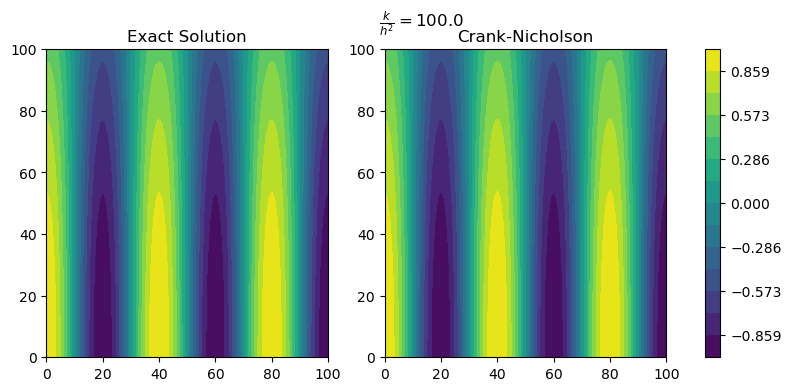

In [172]:
# CN is unconditionally stable

# discretization
xmin,xmax = 0.0,1.0
tmin,tmax = 0.0,1.0
xsteps,tsteps = 101,101 # k/h^2 = 100
xgrid = np.linspace(xmin,xmax,xsteps)
tgrid = np.linspace(tmin,tmax, tsteps)
X,T = np.meshgrid(xgrid,tgrid)

# evaluate boundary terms
u0t = u_exact(xmin,tgrid) # evaluate boundary condition on the grid at x = 0
u1t = u_exact(xmax,tgrid) # evaluate boundary condition on the grid at x = 1
ux0 = u_exact(xgrid,tmin) # evaluate boundary condition on the grid at t = 0

# evaluate sigma
h = xgrid[1] - xgrid[0]
k = tgrid[1] - tgrid[0]
s = k/(h**2)

# evalute Crank-Nicholson solution
u_grid_cn = solveCN(xgrid, tgrid, u0t, u1t, ux0)

# evaluate exact solution
u_grid_exact = u_exact(X,T) 

# global min/max for shared scale of exact-solution and CN-solution
_min = min(u_grid_exact.min(), u_grid_cn.min())
_max = max(u_grid_exact.max(), u_grid_cn.max())
levels = np.linspace(_min, _max, 15)

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
cf1 = ax1.contourf(u_grid_exact, levels=levels)
cf2 = ax2.contourf(u_grid_cn, levels=levels)
ax1.set_title("Exact Solution")
ax2.set_title("Crank-Nicholson")
fig.suptitle(f"$\\frac{{k}}{{h^2}} = {s}$")
fig.colorbar(cf1, ax=[ax1, ax2])
plt.show()


<hr style="height: 10px; border: none; background-color: yellow;">


# Solutions to homework problem

<hr style="height: 10px; border: none; background-color: yellow;">


# Problem 1 - Prove that the exact solutino is $u(x,t) = \cos(5 \pi x) \cos(t)$ 
## Proof 
- Differentiating $u(x,t) = \cos(5 \pi x) \cos(t)$ with respect to $t$ and $x$ we get
    - $u_t = -\cos(5 \pi x) \sin(t)$
    - $u_x = - (5 \pi) \sin(5 \pi x) \cos(t) $
    - $u_{xx} = - (5 \pi)^2 \cos(5 \pi x) \cos(t) $
- $u_{xx} + f(x,t) = -(5 \pi)^2 \cos(5 \pi x) \cos(t) + -\cos(5 \pi x) \sin(t) + (5 \pi)^2 \cos(5 \pi x) \cos(t) = -\cos(5 \pi x) \sin(t)$
- $\therefore u_{xx} + f(x,t) = u_t$ i.e $u(x,t) = \cos(5 \pi x) \cos(t)$ satisfies the differential equation. 
- Substituting $t = 0$ in $u(x,t) = \cos(5 \pi x) \cos(t)$ gives $u(x,0) = \cos(5 \pi x)$
- Substituting $x = 0$ in $u(x,t) = \cos(5 \pi x) \cos(t)$ gives $u(0,t) = \cos(t)$
- Substituting $x = 1$ in $u(x,t) = \cos(5 \pi x) \cos(t)$ gives $u(1,t) = -\cos(t)$
- $\therefore u(x,t) = \cos(5 \pi x) \cos(t)$ satisfies the boundary condition. 
- $\therefore u(x,t) = \cos(5 \pi x) \cos(t)$ satisfies the differential equation and the boundary condition.
- Hence proved that $u(x,t) = \cos(5 \pi x) \cos(t)$ is the exact solution. 

<hr style="height: 10px; border: none; background-color: yellow;">


# Problem 2 - Forward Euler Method
compute the solution using Forward Euler method for 
- $k/h^2 = 1/4 $
- $k/h^2 = 1/2 $
- $k/h^2 = 1 $
    - for $h = 0.1, 0.05, 0.01, 0.005$
- Plot $\ln |e|_2$ vs $\ln k$ for $t = 1$
- Discuss stability and convergence

/tmp/ipykernel_16078/293697159.py:43: RuntimeWarning: overflow encountered in matmul
  rhs = A2 @ uint + s*boundary_l + k*forcing_l
/tmp/ipykernel_16078/293697159.py:43: RuntimeWarning: invalid value encountered in matmul
  rhs = A2 @ uint + s*boundary_l + k*forcing_l


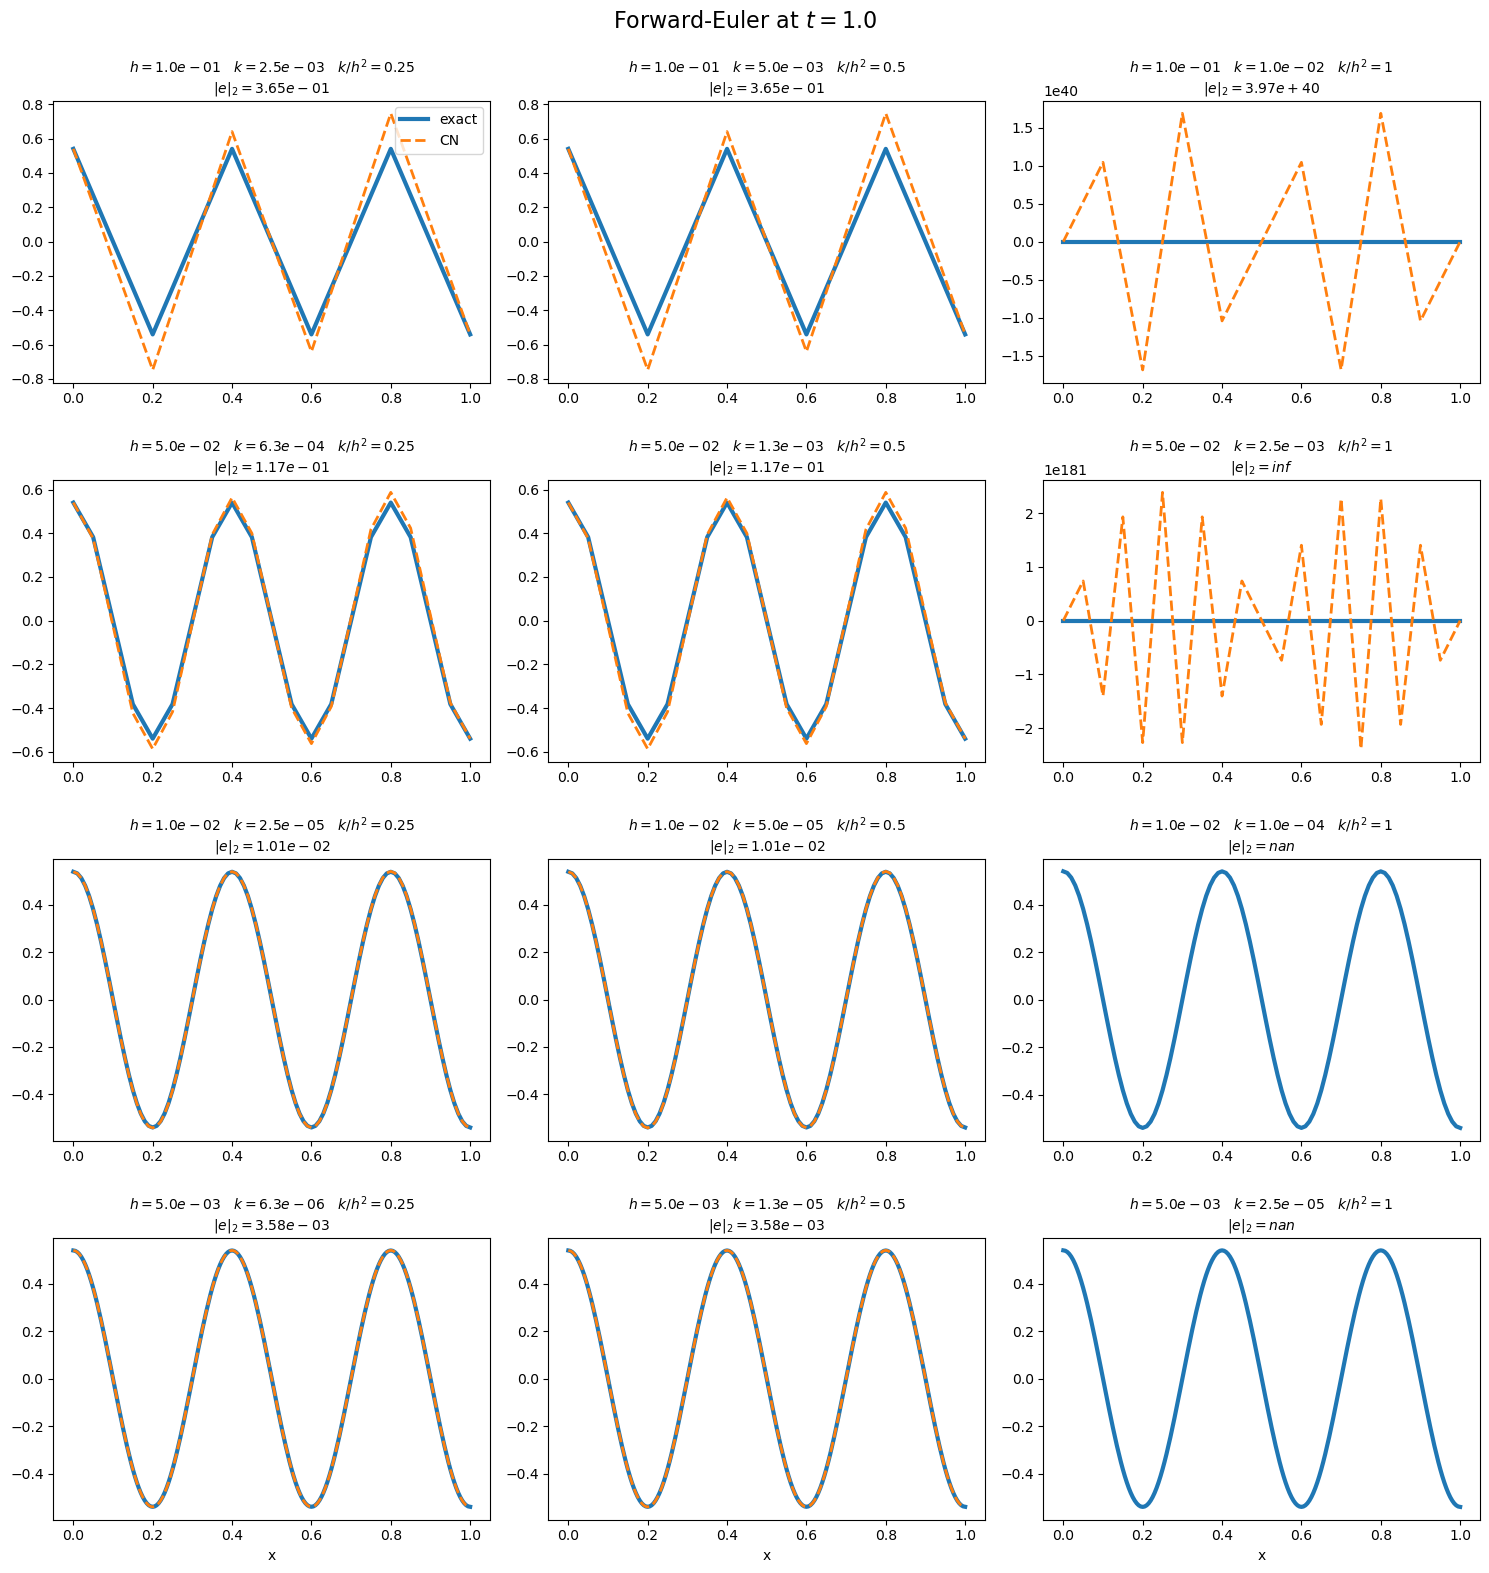

In [154]:
xmin, xmax = 0.0, 1.0
tmin, tmax = 0.0, 1.0

h_values = [1e-1, 5e-2, 1e-2, 5e-3]
ratios = [1/4, 1/2, 1]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

error_values_FE = []
k_values_FE = []
h_values_FE = []
labels_FE = []

for i, h in enumerate(h_values):

    # construct x_grid
    xsteps = int((xmax - xmin)/h) + 1
    xgrid = np.linspace(xmin, xmax, xsteps)

    for j, ratio in enumerate(ratios):
        k = ratio * h * h

        # construct t_grid based on h and k/h
        tsteps = int((tmax - tmin)/k) + 1
        tgrid = np.linspace(tmin, tmax, tsteps)

        # evalute boundary values
        u0t = u_exact(xmin, tgrid)
        u1t = u_exact(xmax, tgrid)
        ux0 = u_exact(xgrid, tmin)

        # solve FE
        u_cn = solveFE(xgrid, tgrid, u0t, u1t, ux0)[-1]
        
        # evaluate exact soltion
        v = u_exact(xgrid, tmax)

        # evaluate norm-2 error
        err = np.linalg.norm(u_cn - v)
        
        error_values_FE.append(err)
        k_values_FE.append(k)
        h_values_FE.append(h)
        labels_FE.append(f"k = {k:.1e}\nh = {h:.1e}\n$|e|_2$={err:.1e}")

        ax = axes[i, j]
        ax.plot(xgrid, v, label="exact", lw=3)
        ax.plot(xgrid, u_cn, "--", label="CN", lw=2)

        ax.set_title(
            f"$h={h:.1e}\\quad k={k:.1e} \\quad k/h^2={ratio} $\n"
            f"$|e|_2={err:.2e}$",
            fontsize=10
        )

        if i == 3:
            ax.set_xlabel("x")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Forward-Euler at $t = 1.0$\n", fontsize=16)
plt.tight_layout()
plt.show()

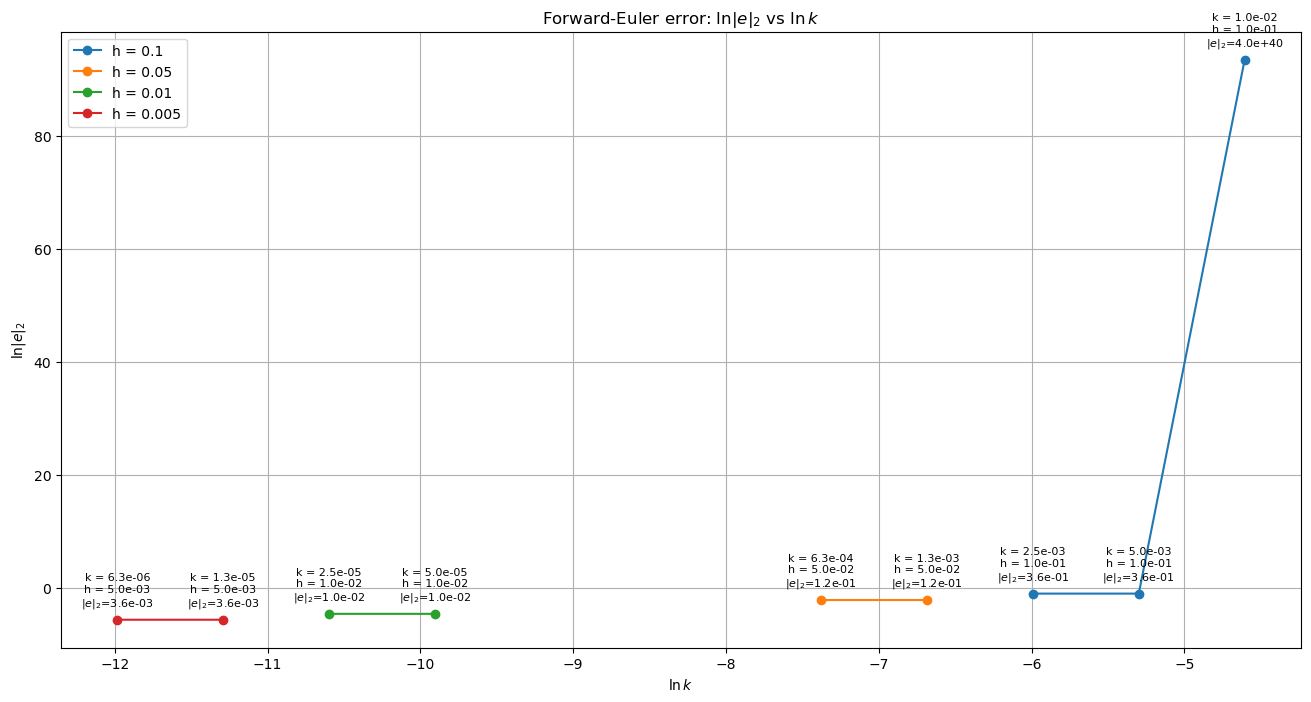

In [155]:
error_values_FE = np.array(error_values_FE)
k_values_FE = np.array(k_values_FE)

plt.figure(figsize=(16,8))
plt.plot(np.log(k_values_FE[0:3]), np.log(error_values_FE[0:3]), "o-", label = f"h = {h_values_FE[0]}") # plot for h = 0.1
plt.plot(np.log(k_values_FE[3:6]), np.log(error_values_FE[3:6]), "o-", label = f"h = {h_values_FE[3]}") # plot for h = 0.05
plt.plot(np.log(k_values_FE[6:9]), np.log(error_values_FE[6:9]), "o-", label = f"h = {h_values_FE[6]}") # plot for h = 0.01
plt.plot(np.log(k_values_FE[9:12]), np.log(error_values_FE[9:12]), "o-", label = f"h = {h_values_FE[9]}") # plot for h = 0.005
plt.xlabel(r"$\ln k$")
plt.ylabel(r"$\ln|e|_2$")
plt.title(r"Forward-Euler error: $\ln|e|_2$ vs $\ln k$")
for i, txt in enumerate(labels_FE):
    plt.annotate(txt, (np.log(k_values_FE)[i], np.log(error_values_FE)[i]), textcoords="offset points", xytext=(0,10), ha='center',fontsize=8)

# plt.ylim(np.log(error_values_FE).min()*1.10,np.log(error_values_FE).max()*0.5)
plt.grid(True)
plt.legend()
plt.show()

### Stability and Convergence of FE method 
- We see that Forward Euler is stable only for $k/h^2 \leq 0.5$
- At $h=0.1, k =0.005$ we have $k/h^2 = 0.5$ i.e this is the limit of stability. But when $k=0.01$ then $k/h^2 = 1.0$ and the error blows up. 
- For the FE method, $|e|_2 \approx C_1k + C_2h^2$ i.e the error scales quadratically with space-discretization and linearly with time-discretization.
- The constant $C_1 \approx |u_{tt}|$. For the exact solution $u = \cos(5 \pi x) \cos(t) $ the maximum value of $|u_{tt}| = 1$
- The constant $C_2 \approx |u_{xxxx}|$. For the exact solution $u = \cos(5 \pi x) \cos(t) $ the maximum value of $|u_{xxxx}| = (5\pi)^4 = 60880.68$
- The vast difference between $C_1$ and $C_2$ explains why spatial-discretizatin contributes more to the error when we are the in region of $k/h^2 \leq 0.5$


<hr style="height: 10px; border: none; background-color: yellow;">


# Problem 3 - Backwards Euler Method
compute the solution using Backward Euler method for 
- $k/h^2 = 1/4 $
- $k/h^2 = 1/2 $
- $k/h^2 = 1 $
    - for $h = 0.1, 0.05, 0.01, 0.005$
- Plot $\ln |e|_2$ vs $\ln k$ for $t = 1$
- Discuss stability and convergence

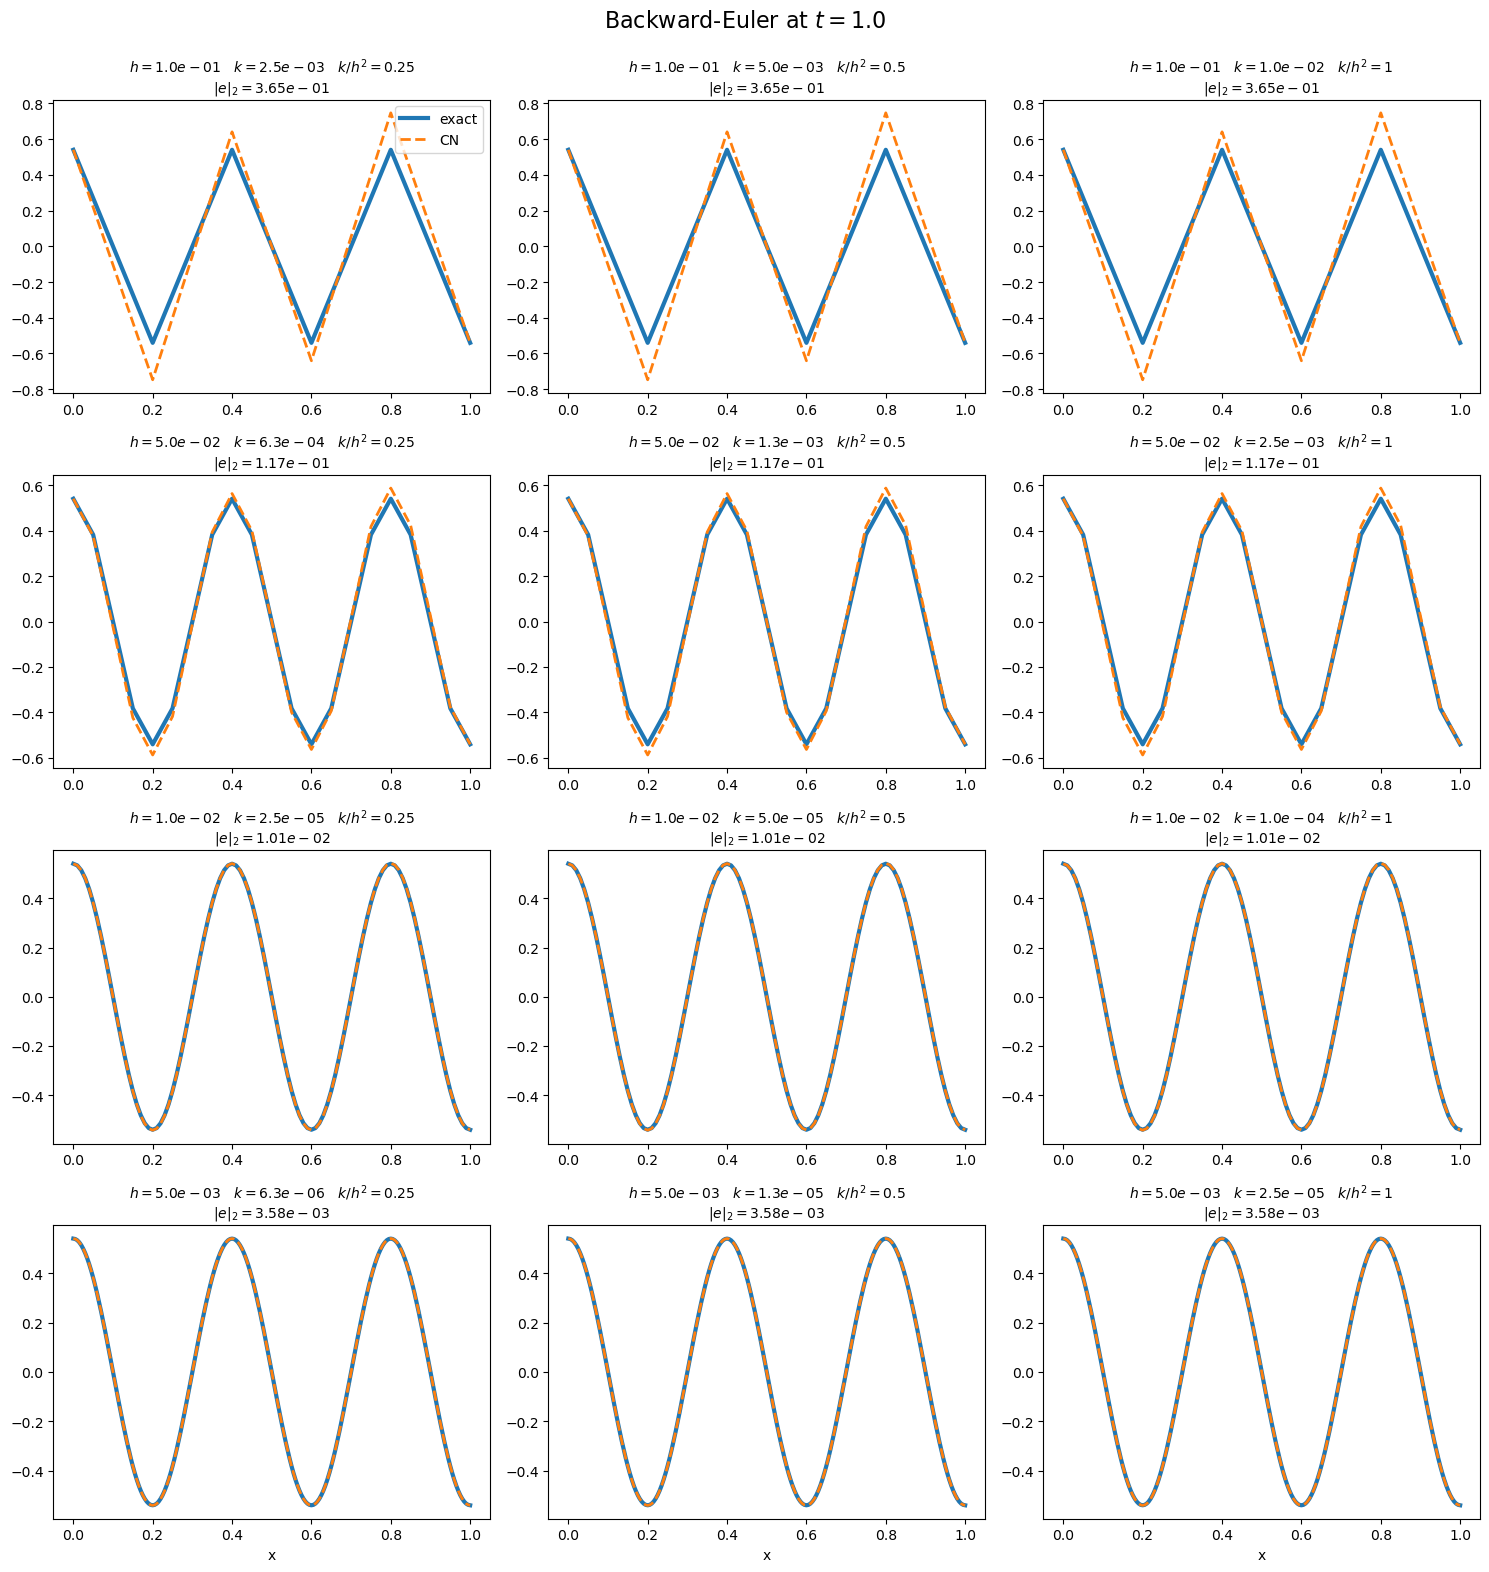

In [146]:
xmin, xmax = 0.0, 1.0
tmin, tmax = 0.0, 1.0

h_values = [1e-1, 5e-2, 1e-2, 5e-3]
ratios = [1/4, 1/2, 1]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

error_values_BE = []
k_values_BE = []
h_values_BE = []
labels_BE = []

for i, h in enumerate(h_values):

    # construct x_grid
    xsteps = int((xmax - xmin)/h) + 1
    xgrid = np.linspace(xmin, xmax, xsteps)

    for j, ratio in enumerate(ratios):
        k = ratio * h * h

        # construct t_grid based on h and k/h
        tsteps = int((tmax - tmin)/k) + 1
        tgrid = np.linspace(tmin, tmax, tsteps)

        # evalute boundary values
        u0t = u_exact(xmin, tgrid)
        u1t = u_exact(xmax, tgrid)
        ux0 = u_exact(xgrid, tmin)

        # solve BE
        u_cn = solveBE(xgrid, tgrid, u0t, u1t, ux0)[-1]
        
        # evaluate exact soltion
        v = u_exact(xgrid, tmax)

        # evaluate norm-2 error
        err = np.linalg.norm(u_cn - v)
        
        error_values_BE.append(err)
        k_values_BE.append(k)
        h_values_BE.append(h)
        labels_BE.append(f"k = {k:.1e}\nh = {h:.1e}\n$|e|_2$={err:.1e}")

        ax = axes[i, j]
        ax.plot(xgrid, v, label="exact", lw=3)
        ax.plot(xgrid, u_cn, "--", label="CN", lw=2)

        ax.set_title(
            f"$h={h:.1e}\\quad k={k:.1e} \\quad k/h^2={ratio} $\n"
            f"$|e|_2={err:.2e}$",
            fontsize=10
        )

        if i == 3:
            ax.set_xlabel("x")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Backward-Euler at $t = 1.0$\n", fontsize=16)
plt.tight_layout()
plt.show()

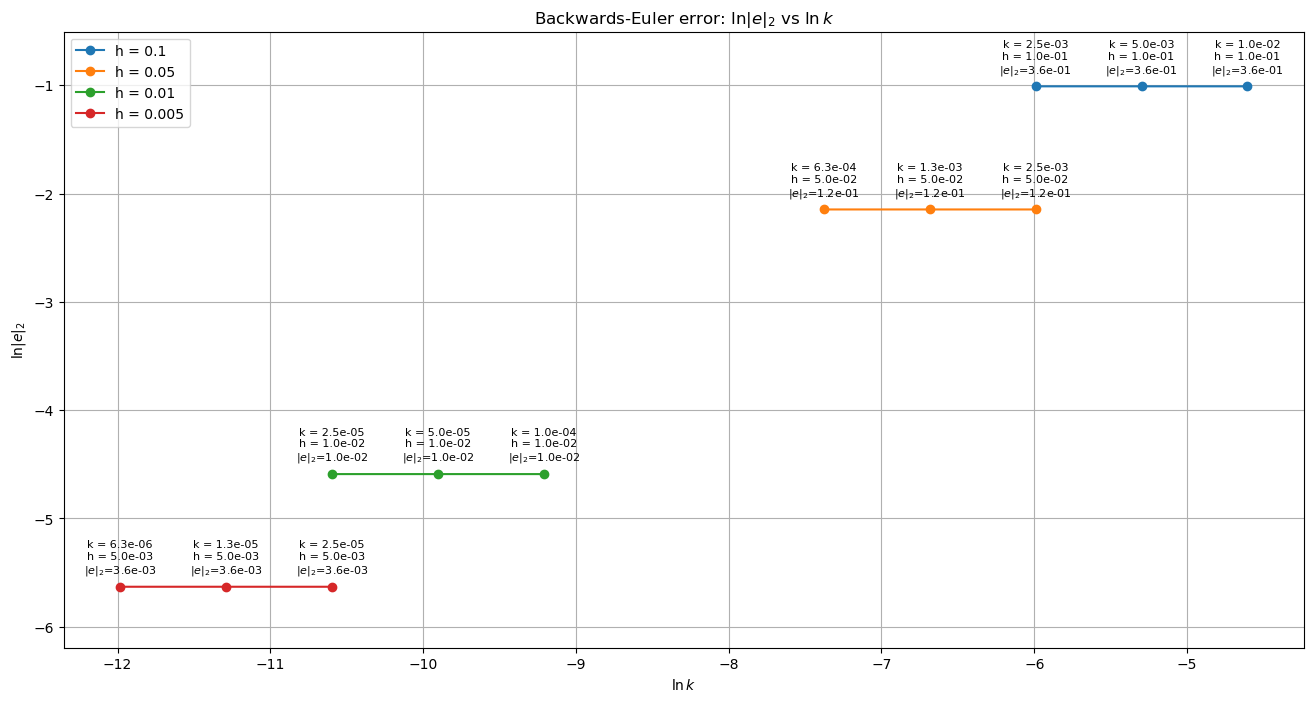

In [157]:
error_values_BE = np.array(error_values_BE)
k_values_BE = np.array(k_values_BE)

plt.figure(figsize=(16,8))
plt.plot(np.log(k_values_BE[0:3]), np.log(error_values_BE[0:3]), "o-", label = f"h = {h_values_BE[0]}") # plot for h = 0.1
plt.plot(np.log(k_values_BE[3:6]), np.log(error_values_BE[3:6]), "o-", label = f"h = {h_values_BE[3]}") # plot for h = 0.05
plt.plot(np.log(k_values_BE[6:9]), np.log(error_values_BE[6:9]), "o-", label = f"h = {h_values_BE[6]}") # plot for h = 0.01
plt.plot(np.log(k_values_BE[9:12]), np.log(error_values_BE[9:12]), "o-", label = f"h = {h_values_BE[9]}") # plot for h = 0.005
plt.xlabel(r"$\ln k$")
plt.ylabel(r"$\ln|e|_2$")
plt.title(r"Backwards-Euler error: $\ln|e|_2$ vs $\ln k$")
for i, txt in enumerate(labels_BE):
    plt.annotate(txt, (np.log(k_values_BE)[i], np.log(error_values_BE)[i]), textcoords="offset points", xytext=(0,10), ha='center',fontsize=8)

plt.ylim(np.log(error_values_BE).min()*1.10,np.log(error_values_BE).max()*0.5)
plt.grid(True)
plt.legend()
plt.show()

In [152]:
(5 * PI)**4

60880.68189625152

### Stability and Convergence of BE method 
- The error remains small even for large $k$ and $h$. This agrees with theory that BE method is unconditionally stable
- For the BE method, $|e|_2 \approx C_1k + C_2h^2$ i.e the error scales quadratically with space-discretization and linearly with time-discretization.
- The constant $C_1 \approx |u_{tt}|$. For the exact solution $u = \cos(5 \pi x) \cos(t) $ the maximum value of $|u_tt| = 1$
- The constant $C_2 \approx |u_{xxxx}|$. For the exact solution $u = \cos(5 \pi x) \cos(t) $ the maximum value of $|u_{xxxx}| = (5\pi)^4 = 60880.68$
- The vast difference between $C_1$ and $C_2$ explains why spatial-discretizatin contributes more to the error. 

<hr style="height: 10px; border: none; background-color: yellow;">


# Problem 4 - Trapezoidal Method
compute the solution using Trapezoidal method for 
- $k/h^2 = 1/4 $
- $k/h^2 = 1 $
- $k/h^2 = 4 $
    - for $h = 0.1, 0.05, 0.01, 0.005$
- Plot $\ln |e|_2$ vs $\ln k$ for $t = 1$
- Discuss stability and convergence

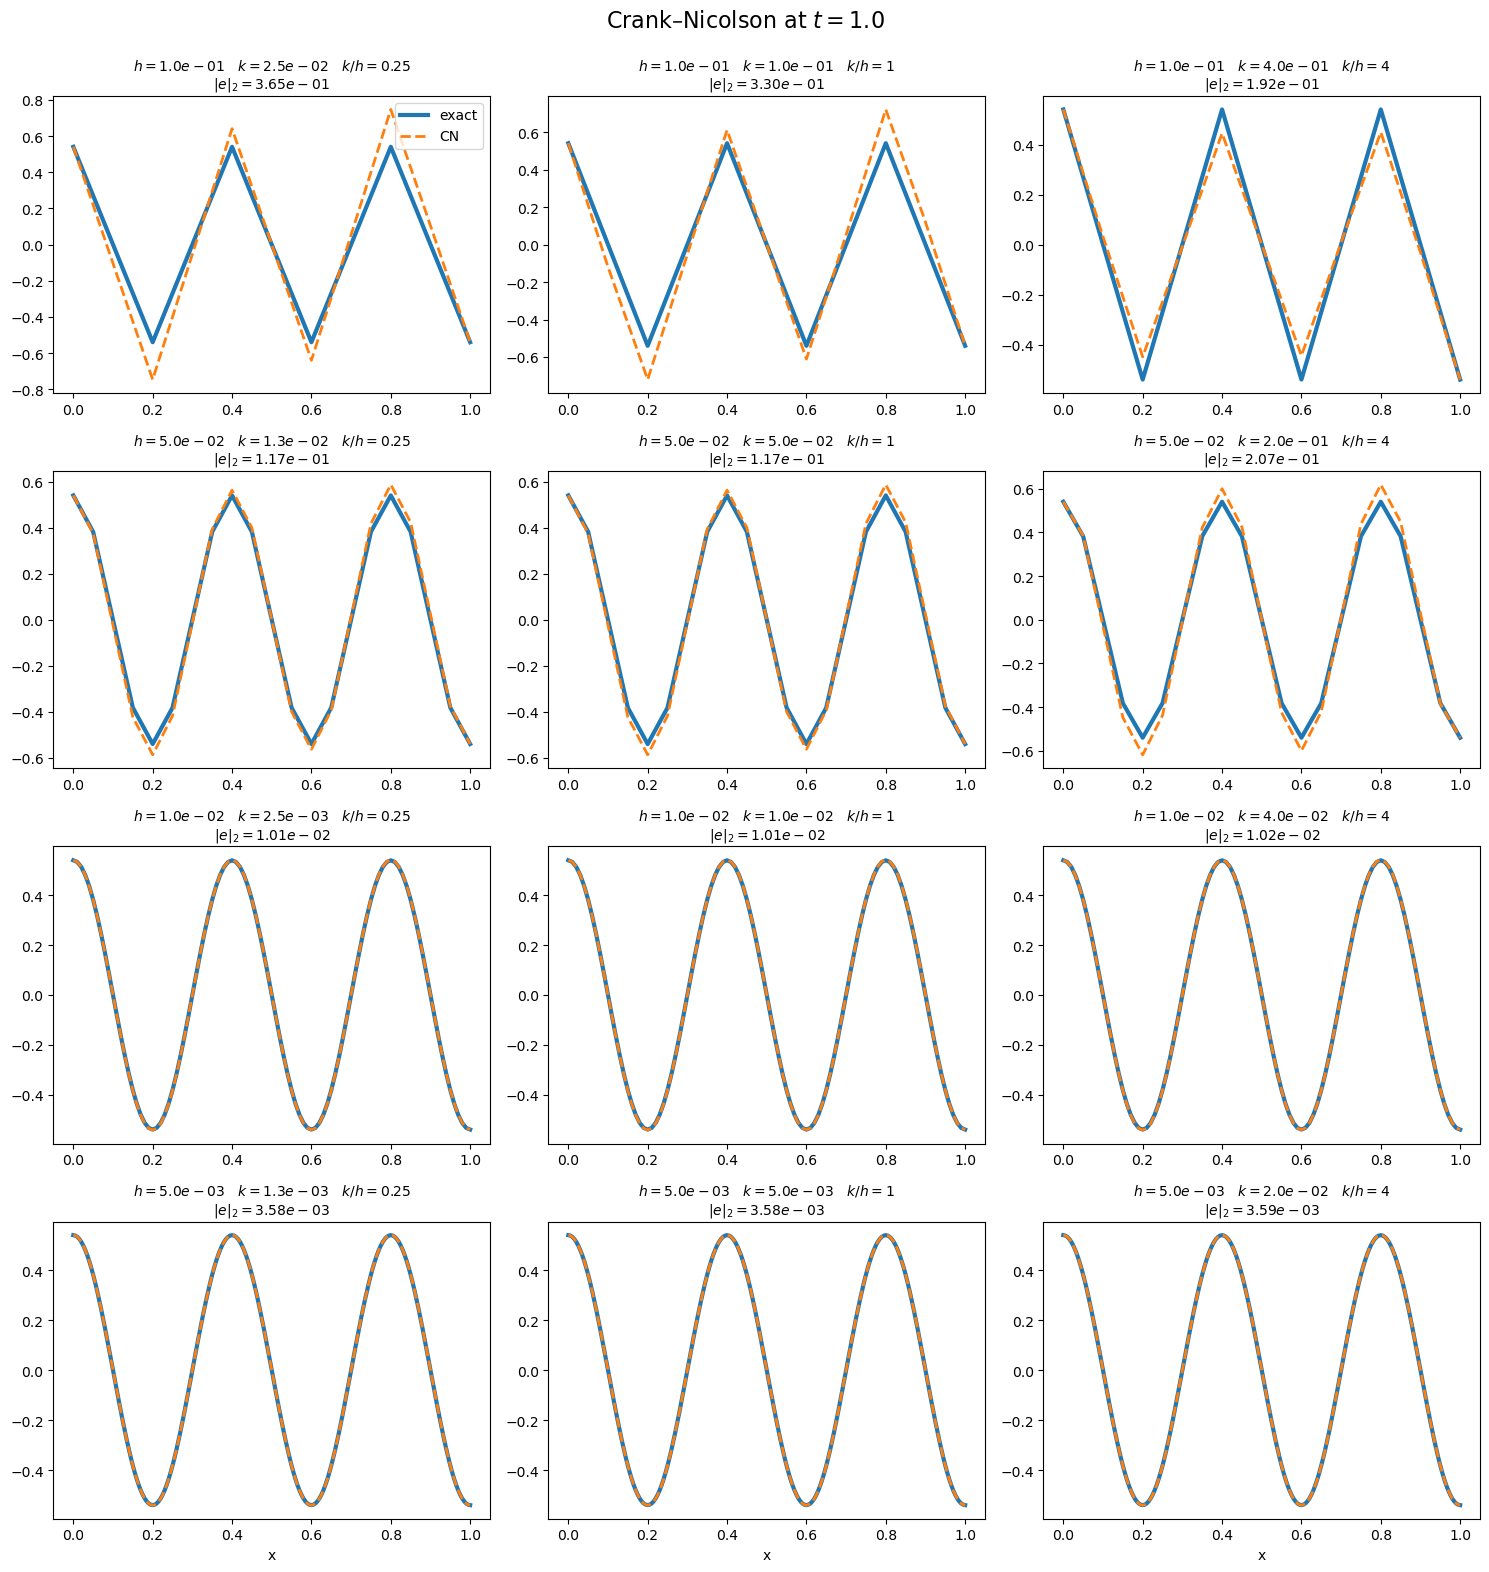

In [140]:
xmin, xmax = 0.0, 1.0
tmin, tmax = 0.0, 1.0

h_values = [1e-1, 5e-2, 1e-2, 5e-3]
ratios = [1/4, 1, 4]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

error_values_CN = []
k_values_CN = []
h_values_CN = []
labels_CN = []

for i, h in enumerate(h_values):

    # construct x_grid
    xsteps = int((xmax - xmin)/h) + 1
    xgrid = np.linspace(xmin, xmax, xsteps)

    for j, ratio in enumerate(ratios):
        k = ratio * h

        # construct t_grid based on h and k/h
        tsteps = int((tmax - tmin)/k) + 1
        tgrid = np.linspace(tmin, tmax, tsteps)

        # evalute boundary values
        u0t = u_exact(xmin, tgrid)
        u1t = u_exact(xmax, tgrid)
        ux0 = u_exact(xgrid, tmin)

        # solve CN
        u_cn = solveCN(xgrid, tgrid, u0t, u1t, ux0)[-1]
        
        # evaluate exact soltion
        v = u_exact(xgrid, tmax)

        # evaluate norm-2 error
        err = np.linalg.norm(u_cn - v)
        
        error_values_CN.append(err)
        k_values_CN.append(k)
        h_values_CN.append(h)
        labels_CN.append(f"k = {k:.1e}\nh = {h:.1e}\n$|e|_2$={err:.2e}")

        ax = axes[i, j]
        ax.plot(xgrid, v, label="exact", lw=3)
        ax.plot(xgrid, u_cn, "--", label="CN", lw=2)

        ax.set_title(
            f"$h={h:.1e}\\quad k={k:.1e} \\quad k/h={ratio} $\n"
            f"$|e|_2={err:.2e}$",
            fontsize=10
        )

        if i == 3:
            ax.set_xlabel("x")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Crank–Nicolson at $t = 1.0$\n", fontsize=16)
plt.tight_layout()
plt.show()

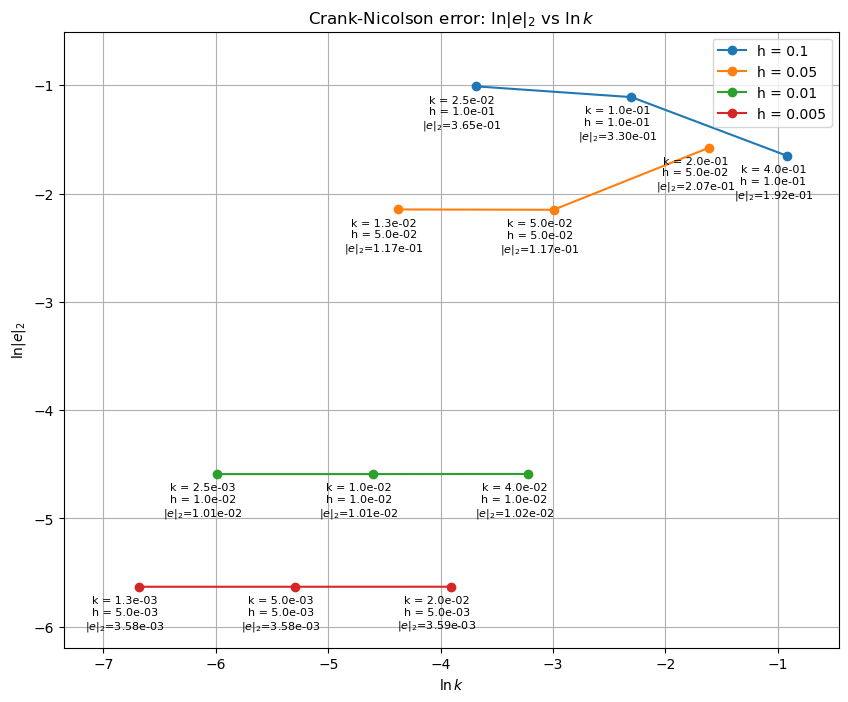

In [158]:
error_values_CN = np.array(error_values_CN)
k_values_CN = np.array(k_values_CN)

plt.figure(figsize=(10,8))
plt.plot(np.log(k_values_CN[0:3]), np.log(error_values_CN[0:3]), "o-", label = f"h = {h_values_CN[0]}") # plot for h = 0.1
plt.plot(np.log(k_values_CN[3:6]), np.log(error_values_CN[3:6]), "o-", label = f"h = {h_values_CN[3]}") # plot for h = 0.05
plt.plot(np.log(k_values_CN[6:9]), np.log(error_values_CN[6:9]), "o-", label = f"h = {h_values_CN[6]}") # plot for h = 0.01
plt.plot(np.log(k_values_CN[9:12]), np.log(error_values_CN[9:12]), "o-", label = f"h = {h_values_CN[9]}") # plot for h = 0.005
plt.xlabel(r"$\ln k$")
plt.ylabel(r"$\ln|e|_2$")
plt.title(r"Crank-Nicolson error: $\ln|e|_2$ vs $\ln k$")
for i, txt in enumerate(labels_CN):
    plt.annotate(txt, (np.log(k_values_CN)[i], np.log(error_values_CN)[i]), textcoords="offset points", xytext=(-10,-30), ha='center',fontsize=8)

plt.ylim(np.log(error_values_CN).min()*1.10,np.log(error_values_CN).max()*0.5)
plt.xlim(np.log(k_values_CN).min()*1.10,np.log(k_values_CN).max()*0.5)
plt.grid(True)
plt.legend()
plt.show()

### Stability and Convergence of CN method 
- The error remains small even for large $k$ and $h$. This agrees with theory that CN method is unconditionally stable
- For the CN method, $|e|_2 \approx C_1k^2 + C_2h^2$ i.e the error scales quadratically with spatial-discretization and time-discretization. For $h=0.005$ and $h=0.01$ the error does not increase significantly with $k$. This is likely because the space-discretization is small enough to restrict errors from blowing up. Moreover the scaling factor $C_1$ might be very small compared to $C_2$
- The constant $C_1 \approx |u_{ttt}|$. For the exact solution $u = \cos(5 \pi x) \cos(t) $ the maximum value of $|u_ttt| = 1$
- The constant $C_2 \approx |u_{xxxx}|$. For the exact solution $u = \cos(5 \pi x) \cos(t) $ the maximum value of $|u_{xxxx}| = (5\pi)^4 = 60880.68$
- The vast difference between $C_1$ and $C_2$ explains why spatial-discretizatin contributes more to the error. 
- For $h = 0.05$ we see a drastic increase in error when $k$ increases from $0.05$ to $0.2$. So I think a "good" grid must have $0.05 \leq k \leq 0.2$
- For $h = 0.1$ the error decreases for larger $k$. I think this anomolous behaviour is due to the discretization being too coarse. When $h=0.1$ and $k=0.4$ the grid is very coarse $(10_x \times 2_t)$. For an oscillatory function such as $\cos(5\pi x) \cos(t)$ this is too coarse for us to extract any meaningful insights about the convergence.
